# SIOC 221A — Homework 1
Jingyi He (jih185)
Collaborators: none 

In [1]:
# Imports, setup and some sanity check
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from netCDF4 import Dataset                     # reading netCDF files 
%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 4.5)       # default figure size for all plots

# Locate the class repository
home = os.path.expanduser('~')
candidates = [
    os.environ.get('SIO221A_ROOT', ''),
    os.path.join('..', '..'),  
    os.path.join(home, 'Documents', 'SIOC221A', 'SIO221a_Github_code_2026'),
]
 # Test for a FILE known to be in the repo, not just the folder: 
 # an empty or half-cloned directory would pass a folder test and then fail confusingly later...
sentinel = os.path.join('data', 'scripps_pier-2020.nc')
course_root = None
for cand in candidates:
    if cand and os.path.isfile(os.path.join(cand, sentinel)):  # skip empty strings
        course_root = cand
        break                                                  # stop at the first match
if course_root is None:
    raise FileNotFoundError('Could not find the class repo.')

# Paths used in the rest of the notebook
data_dir = os.path.join(course_root, 'data')                # class data files
sys.path.append(os.path.join(course_root, 'python_code'))   # class functions, inportable

# Sanity check: show where the repo was found and which data files are available
print('SIO221a repo:', os.path.abspath(course_root))
print(sorted(os.listdir(data_dir)))

SIO221a repo: c:\Users\asus\Documents\SIOC221A\SIO221a_Github_code_2026
['Vel_2008-2009.nc', 'class10_record.mat', 'class10_record_netcf.cdf', 'eps_BLT_example.mat', 'scripps_pier-2020.nc', 'scripps_pier-2021.nc']


In [2]:
# Problem 1a: read the 2021 pier data from the SCCOOS THREDDS server
nc = Dataset('http://sccoos.org/thredds/dodsC/autoss/scripps_pier-2021.nc')

# check units stored in the file's metadata
print('time units:', nc.variables['time'].units) 
print('T units   :', nc.variables['temperature'].units)

# Read time and temperature, replace any bad values with NaN
time21 = np.asarray(nc.variables['time'][:])
T21 = np.ma.filled(nc.variables['temperature'][:].astype(float), np.nan)
nc.close()

# Convert time (seconds) to dates
t21 = time21.astype('datetime64[s]')
print(f'{len(T21)} samples, from {t21[0]} to {t21[-1]}')
print(f'{np.isnan(T21).sum()} NaN values')

# Check the time between samples, and find the longest gap
dt = np.diff(t21) / np.timedelta64(1, 'm')
print(f'median interval = {np.median(dt):.1f} min, max gap = {np.max(dt)/60:.1f} hours')

time units: seconds since 1970-01-01 00:00:00 UTC
T units   : celsius
129244 samples, from 2021-01-01T00:01:35 to 2021-12-31T23:56:00
0 NaN values
median interval = 4.0 min, max gap = 135.2 hours


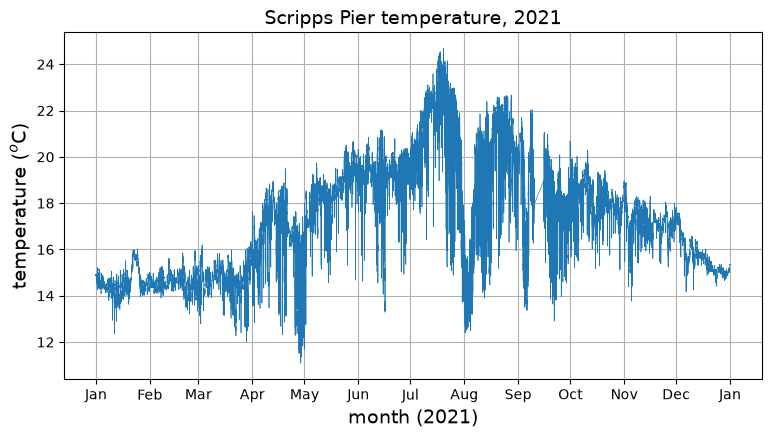

In [3]:
# Plot the 2021 temperature time series
fig, ax = plt.subplots()
ax.plot(t21, T21, linewidth=0.5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Axis labels with units, title and grid
ax.set_xlabel('month (2021)', fontsize=14)
ax.set_ylabel('temperature ($^o$C)', fontsize=14)
ax.set_title('Scripps Pier temperature, 2021', fontsize=14)
ax.grid(True)
plt.show()

In [4]:
# List every gap longer than 1 hour
big = np.where(dt > 60)[0]
for i in big:
    print(f'{t21[i]}  ->  {t21[i+1]}   ({dt[i]/60:.1f} h)')

2021-01-22T16:57:35  ->  2021-01-22T19:14:18   (2.3 h)
2021-09-10T03:10:18  ->  2021-09-15T18:24:00   (135.2 h)
2021-11-25T02:20:00  ->  2021-11-25T04:32:00   (2.2 h)


### 1a. Observations

- **Record coverage.** The 2021 record from the SCCOOS server runs from 1 January to 31 December 2021: 129,244 samples at 4-minute intervals, about 98 % of the samples expected for a full year. There are 3 gaps longer than an hour: 2.3 h on 22 January, 135.2 h from 10 to 15 September, and 2.2 h on 25 November. The straight line across mid-September in the plot is matplotlib connecting the two ends of that gap, not real data.
- **Seasonal cycle.** January–March temperatures are cool and fairly steady, around 14–16 °C. Warming begins in April, and temperatures reach their maximum of about 24.5 °C in late July. They then decline through the autumn, with monthly means of roughly 18 °C in October, 17 °C in November and 15.7 °C in December, so by the end of the year the water has returned close to its winter values.
- **Variability changes with season.** In winter the high-frequency variability is small. From April onward the record becomes much noisier. Temperatures frequently drop by 4–8 °C within hours to a day and then recover. These rapid cold events are consistent with the stronger summer stratification, when internal tides and upwelling can bring cold water from below up to the sensor. The variability decreases again as the water cools in late autumn.

In [5]:
# Problem 1b: mean and standard deviation of the 2021 record
# skip any NaN values
mean21 = np.nanmean(T21)
std21 = np.nanstd(T21, ddof=1)
print(f'2021: mean = {mean21:.2f} degC, std = {std21:.2f} degC')

# Repeat for each month, to see how the mean and spread change through the year
months = t21.astype('datetime64[M]').astype(int) % 12 + 1 # 1 = Jan, ..., 12 = Dec
print('\nmonth   mean    std      N')
for m in range(1, 13):
    sel = months == m  # pick out the samples in month m
    print(f'{m:5d}  {np.nanmean(T21[sel]):5.2f}  {np.nanstd(T21[sel], ddof=1):5.2f}  {sel.sum():5d}')

2021: mean = 17.27 degC, std = 2.43 degC

month   mean    std      N
    1  14.58   0.53  11126
    2  14.52   0.37  10071
    3  14.68   0.66  11155
    4  16.58   1.41  10797
    5  18.47   0.99  11159
    6  19.24   0.95  10797
    7  21.14   1.98  11145
    8  18.99   2.67  11158
    9  18.05   1.89   8758
   10  18.14   0.80  11154
   11  17.15   0.65  10768
   12  15.67   0.68  11156


### 1b. Mean and standard deviation

For 2021, the mean temperature is **17.27 °C** and the standard deviation is **2.43 °C**.

- **The standard deviation mostly reflects the seasonal cycle.** Monthly means rise from about 14.5 °C (Jan–Mar) to 21.1 °C (July) and fall back to 15.7 °C (December). Within a single month, the spread is much smaller. Under 0.8 °C in winter and autumn, and 1.9–2.7 °C in summer, when rapid cold events are common.
- **Mean ± std does not describe a typical day.** Because both the mean and the variability change through the year, the record is not stationary. 17.27 ± 2.43 °C fits neither a typical winter day (about 14.5 ± 0.5 °C) nor a typical summer day (about 19–21 °C, with large swings).

integral of PDF = 1.0


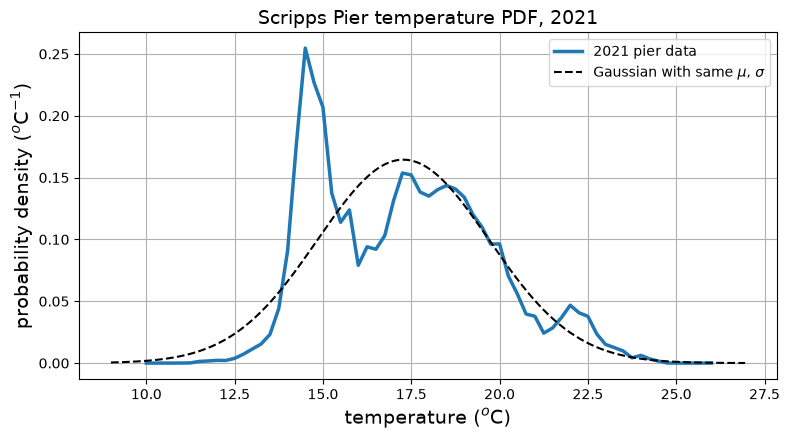

skewness = 0.42, excess kurtosis = -0.56


In [6]:
# Problem 1c: empirical probability density function
from scipy import stats

bin_size = 0.25
bins = np.arange(10, 26 + bin_size, bin_size)                  # bin centres
edges = np.append(bins - bin_size/2, bins[-1] + bin_size/2)    # numpy histogram edges
good = ~np.isnan(T21)
counts, _ = np.histogram(T21[good], bins=edges)
pdf21 = counts / counts.sum() / bin_size                       # counts to probability density
print('integral of PDF =', (pdf21 * bin_size).sum())           # must be 1

# Gaussian with the same mean and std
x = np.arange(9, 27, 0.05)
gauss = 1/(std21*np.sqrt(2*np.pi)) * np.exp(-(x - mean21)**2 / (2*std21**2))

fig, ax = plt.subplots()
ax.plot(bins, pdf21, linewidth=2.5, label='2021 pier data')
ax.plot(x, gauss, 'k--', linewidth=1.5, label=r'Gaussian with same $\mu$, $\sigma$')
ax.set_xlabel('temperature ($^o$C)', fontsize=14)
ax.set_ylabel('probability density ($^o$C$^{-1}$)', fontsize=14)
ax.set_title('Scripps Pier temperature PDF, 2021', fontsize=14)
ax.legend(loc='best')
ax.grid(True)
plt.show()

# Skewness and excess kurtosis are both 0 for a Gaussian
print(f'skewness = {stats.skew(T21[good]):.2f}, '
      f'excess kurtosis = {stats.kurtosis(T21[good]):.2f}')

### 1c. Empirical PDF

The PDF is clearly **not Gaussian**:

- **A narrow peak at about 14.5 °C** comes from January–March, when temperatures are cool and steady.
- **A broad peak around 17–19 °C** comes from the warmer months (late spring through autumn), with a warm tail reaching about 24 °C in summer. Between the two peaks there is a dip near 16 °C.
- **The Gaussian with the same μ and σ fits poorly.** It misses the winter peak and puts too much probability below about 13.5 °C. The skewness (0.42) shows a longer warm tail, and the negative excess kurtosis (−0.56) shows a flatter shape than a Gaussian.

It most resembles the **bimodal**. A mix of a narrow winter distribution and a broad warm-season one. As in the "spring" example from Lecture 2, this shape comes from non-stationarity. Because the mean changes through the year, the PDF combines different seasons rather than describing a single random process.

In [7]:
# Problem 2: read 2005-2021 from the SCCOOS THREDDS server and stitch together
base_url = 'http://sccoos.org/thredds/dodsC/autoss/scripps_pier-{}.nc'   # {} is replaced by the year
cache = os.path.join(home, 'sio221a_pier_2005_2021.npz')  # saved copy, kept outside the repo

if os.path.isfile(cache):
    # already downloaded before, just load the saved copy, faster
    d = np.load(cache)
    t_all, T_all = d['t'], d['T']
    print('loaded from cache:', cache)
else:
    # download each year in a loop
    t_list, T_list = [], []                             # one entry per year
    for year in range(2005, 2022):                      # 2005 to 2021
        try:
            nc = Dataset(base_url.format(year))
        except OSError as err:                          # skip the year if its file can not be opened
            print(f'{year}: could not open ({err})')
            continue

        # read time and temp
        units = nc.variables['time'].units
        tt = np.asarray(nc.variables['time'][:]).astype('datetime64[s]')
        TT = np.ma.filled(nc.variables['temperature'][:].astype(float), np.nan)
        nc.close()

        # warn if a file stores time differently from the others
        if not units.startswith('seconds since 1970-01-01'):
            print(f'  WARNING {year}: unexpected time units "{units}"')

        # quick sanity check of samples, time range, sampling interval, temp range for each year
        dt_med = np.median(np.diff(tt)) / np.timedelta64(1, 'm')
        print(f'{year}: {len(TT):6d} samples, {tt[0]} to {tt[-1]}, '
              f'median dt = {dt_med:4.1f} min, T = {np.nanmin(TT):5.1f} to {np.nanmax(TT):5.1f} degC')
        t_list.append(tt)
        T_list.append(TT)

    # join all years into one long record and save it for next time
    t_all = np.concatenate(t_list)
    T_all = np.concatenate(T_list)
    np.savez(cache, t=t_all, T=T_all)
    print('saved cache:', cache)

# Sort by time and remove any repeated times
order = np.argsort(t_all)
t_all, T_all = t_all[order], T_all[order]
keep = np.concatenate([[True], np.diff(t_all) > np.timedelta64(0, 's')])
t_all, T_all = t_all[keep], T_all[keep]

# Basic quality control: flag physically implausible values as NaN
bad = (T_all < 5) | (T_all > 35)
print(f'{bad.sum()} values outside 5-35 degC set to NaN')
T_all[bad] = np.nan
print(f'stitched record: {len(T_all)} samples, {t_all[0]} to {t_all[-1]}')

loaded from cache: C:\Users\asus\sio221a_pier_2005_2021.npz
0 values outside 5-35 degC set to NaN
stitched record: 1799019 samples, 2005-06-16T19:28:47 to 2021-12-31T23:56:00


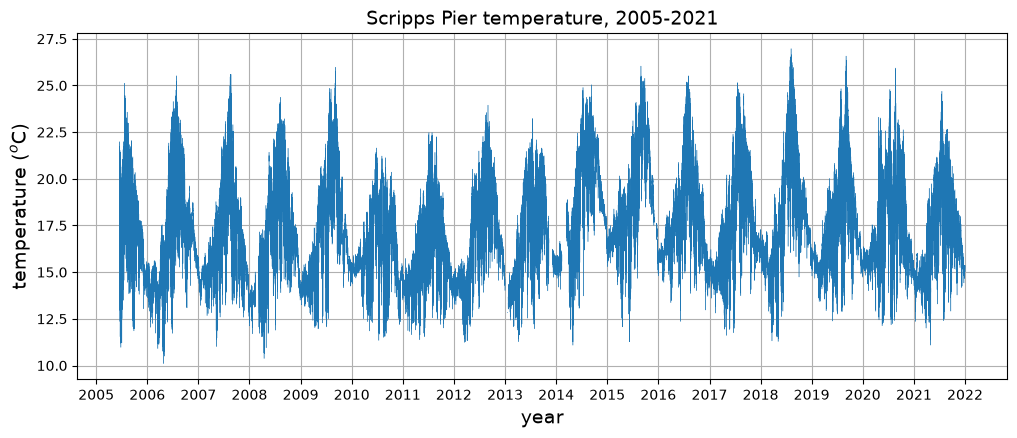

In [8]:
def insert_gaps(t, y, max_gap=np.timedelta64(1, 'D')):
    """Insert a NaN wherever there is a gap longer than max_gap (default: 1 day),
    so the plot shows a break instead of a straight line across missing data."""
    i = np.where(np.diff(t) > max_gap)[0] + 1                   # positions right after each gap
    t_new = np.insert(t, i, t[i - 1] + np.timedelta64(1, 's'))  # add a time just after the gap starts
    y_new = np.insert(y.astype(float), i, np.nan)               # with a NaN value, so the line breaks
    return t_new, y_new

# Plot the full 2005-2021 record, with breaks at the gaps
tp, Tp = insert_gaps(t_all, T_all)
fig, ax = plt.subplots(figsize=(12, 4.5))                       # wider figure for 17 years
ax.plot(tp, Tp, linewidth=0.3)                                  # very thin line: lots of points

# One tick per year on the x-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Axis labels, title and grid
ax.set_xlabel('year', fontsize=14)
ax.set_ylabel('temperature ($^o$C)', fontsize=14)
ax.set_title('Scripps Pier temperature, 2005-2021', fontsize=14)
ax.grid(True)
plt.show()

In [9]:
# Per-year summary of the stitched record. coverage, sampling interval and largest gap
years = t_all.astype('datetime64[Y]').astype(int) + 1970
for yr in np.unique(years):
    sel = years == yr
    dt_yr = np.diff(t_all[sel]) / np.timedelta64(1, 'm')
    print(f'{yr}: {sel.sum():7d} samples, {t_all[sel][0]} to {t_all[sel][-1]}, '
          f'median dt = {np.median(dt_yr):4.1f} min, largest gap = {dt_yr.max()/60/24:5.1f} days')

2005:   66778 samples, 2005-06-16T19:28:47 to 2005-12-31T23:59:27, median dt =  4.0 min, largest gap =   5.9 days
2006:  124067 samples, 2006-01-01T00:03:27 to 2006-12-31T23:55:27, median dt =  4.0 min, largest gap =   2.4 days
2007:   98486 samples, 2007-01-01T00:03:27 to 2007-12-31T23:54:34, median dt =  4.0 min, largest gap =   1.0 days
2008:   61263 samples, 2008-01-01T00:02:34 to 2008-12-31T23:52:56, median dt =  8.0 min, largest gap =  24.3 days
2009:   63177 samples, 2009-01-01T00:00:56 to 2009-12-31T23:59:25, median dt =  8.0 min, largest gap =   3.0 days
2010:   60888 samples, 2010-01-01T00:07:25 to 2010-12-31T23:53:16, median dt =  8.0 min, largest gap =   8.1 days
2011:   64600 samples, 2011-01-01T00:01:16 to 2011-12-31T23:58:15, median dt =  8.0 min, largest gap =   2.2 days
2012:   96052 samples, 2012-01-01T00:06:15 to 2012-12-31T23:58:12, median dt =  4.0 min, largest gap =   6.2 days
2013:  193343 samples, 2013-01-18T22:29:25 to 2013-12-31T23:57:13, median dt =  2.0 min,

2005-2021: mean = 17.80 degC, std = 2.74 degC, N = 1799018
2021     : mean = 17.27 degC, std = 2.43 degC, N = 129244
2005-2021: skewness = 0.39, excess kurtosis = -0.59


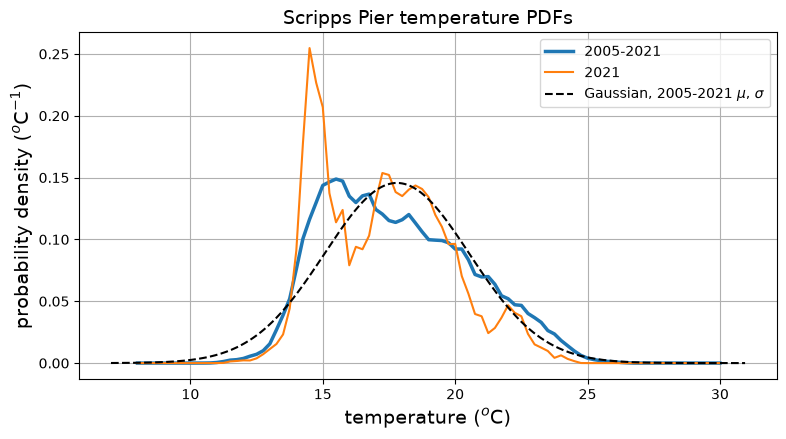

In [10]:
# Problem 2b/2c: statistics and PDF of the full record, compared with 2021
good_all = ~np.isnan(T_all)
mean_all = np.nanmean(T_all)
std_all = np.nanstd(T_all, ddof=1)
print(f'2005-2021: mean = {mean_all:.2f} degC, std = {std_all:.2f} degC, N = {good_all.sum()}')
print(f'2021     : mean = {mean21:.2f} degC, std = {std21:.2f} degC, N = {good.sum()}')
print(f'2005-2021: skewness = {stats.skew(T_all[good_all]):.2f}, '
      f'excess kurtosis = {stats.kurtosis(T_all[good_all]):.2f}')

bin_size = 0.25
bins = np.arange(8, 30 + bin_size, bin_size)
edges = np.append(bins - bin_size/2, bins[-1] + bin_size/2)
counts_all, _ = np.histogram(T_all[good_all], bins=edges)
pdf_all = counts_all / counts_all.sum() / bin_size
counts21, _ = np.histogram(T21[good], bins=edges)
pdf21b = counts21 / counts21.sum() / bin_size

x = np.arange(7, 31, 0.05)
gauss_all = 1/(std_all*np.sqrt(2*np.pi)) * np.exp(-(x - mean_all)**2 / (2*std_all**2))

fig, ax = plt.subplots()
ax.plot(bins, pdf_all, linewidth=2.5, label='2005-2021')
ax.plot(bins, pdf21b, linewidth=1.5, label='2021')
ax.plot(x, gauss_all, 'k--', linewidth=1.5, label=r'Gaussian, 2005-2021 $\mu$, $\sigma$')
ax.set_xlabel('temperature ($^o$C)', fontsize=14)
ax.set_ylabel('probability density ($^o$C$^{-1}$)', fontsize=14)
ax.set_title('Scripps Pier temperature PDFs', fontsize=14)
ax.legend(loc='best')
ax.grid(True)
plt.show()

month  2021   clim  clim_std   anomaly(std)
    1  14.59  15.03    0.84     -0.53
    2  14.52  15.08    0.83     -0.68
    3  14.68  15.39    1.22     -0.58
    4  16.58  15.99    0.79      0.74
    5  18.47  17.70    0.81      0.96
    6  19.24  18.90    0.87      0.39
    7  21.14  20.28    1.44      0.60
    8  18.99  20.38    1.77     -0.79
    9  18.06  19.87    1.99     -0.91
   10  18.14  18.82    1.45     -0.47
   11  17.15  17.33    1.08     -0.17
   12  15.67  15.68    0.92     -0.01


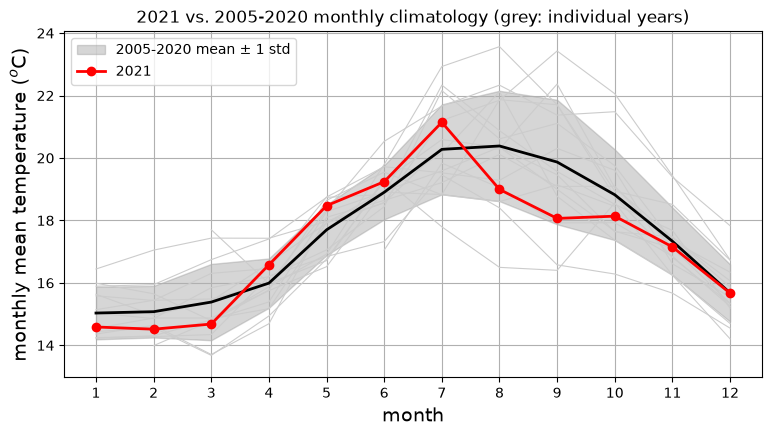

In [ ]:
# Is 2021 unusual? Compare each month of 2021 with the 2005-2020 average for that month
# For this question I asked AI(Claude) help to generate some idea of how to compare 
# (visually describe the difference between 2021 data to others)
import pandas as pd

# Daily means first, so every day counts equally
s = pd.Series(T_all, index=pd.to_datetime(t_all))
daily = s.resample('D').mean()

# Monthly means, skipping months with too little data
monthly = daily.resample('MS').mean()
ndays = daily.resample('MS').count()  # number of days with data in each month
monthly[ndays < 15] = np.nan          # need at least 15 days to trust a monthly mean

# Rearrange into a table: one row per month, one column per year
tab = monthly.to_frame('T')
tab['year'] = tab.index.year
tab['month'] = tab.index.month
table = tab.pivot(index='month', columns='year', values='T')

# "Normal" conditions: average and spread of each month over 2005-2020
clim = table.loc[:, 2005:2020]
clim_mean = clim.mean(axis=1)         # average over the years, for each month
clim_std = clim.std(axis=1, ddof=1)   # year-to-year spread, for each month

# How far 2021 is from normal, in units of the year-to-year spread
z21 = (table[2021] - clim_mean) / clim_std

print('month  2021   clim  clim_std   anomaly(std)')
for m in range(1, 13):
    print(f'{m:5d}  {table.loc[m, 2021]:5.2f}  {clim_mean[m]:5.2f}  {clim_std[m]:6.2f}  {z21[m]:8.2f}')

# Plot each past year in grey, the normal range as a shaded band, 2021 in red
fig, ax = plt.subplots()
for yr in clim.columns:
    ax.plot(table.index, table[yr], color='0.8', linewidth=0.8)
ax.fill_between(table.index, clim_mean - clim_std, clim_mean + clim_std,
                color='0.6', alpha=0.4, label=r'2005-2020 mean $\pm$ 1 std')
ax.plot(table.index, clim_mean, 'k', linewidth=2)                 # black is 2005-2020 average
ax.plot(table.index, table[2021], 'r-o', linewidth=2, label='2021')

# Axes, labels, title and grid
ax.set_xticks(range(1, 13))
ax.set_xlabel('month', fontsize=14)
ax.set_ylabel('monthly mean temperature ($^o$C)', fontsize=14)
ax.set_title('2021 vs. 2005-2020 monthly climatology (grey: individual years)', fontsize=12)
ax.legend(loc='best')
ax.grid(True)
plt.show()

Largest 6-day drop in Aug 2016 (daily means): -7.55 degC, ending 2016-08-18
Fraction of all 6-day changes this negative:       0.07 %
Fraction of summer (Jun-Sep) changes this negative: 0.20 %


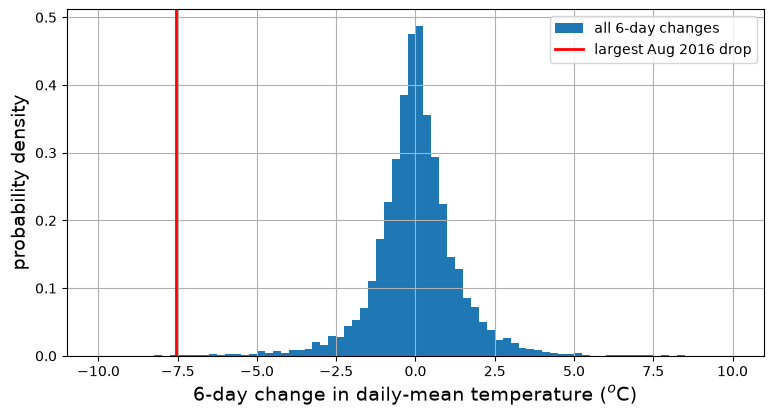

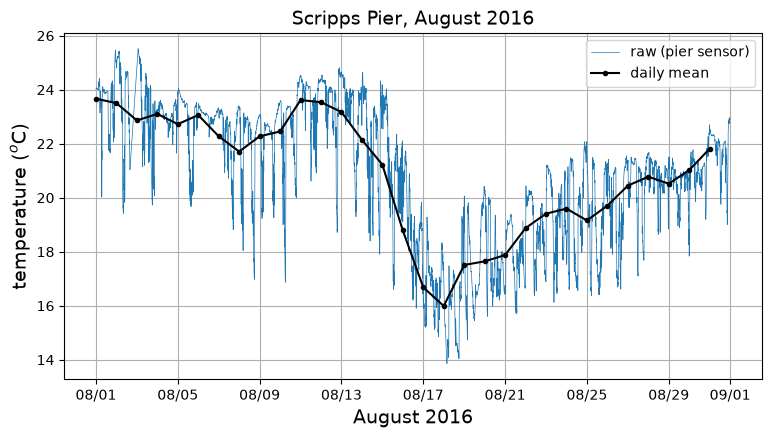

In [12]:
# Is the August 2016 drop unusual?
# The 2016 email reported ~25 -> 17.2 degC (a 7.8 degC drop) over six days.
# Compute the 6-day change in daily-mean temperature for the whole record,
# then see where August 2016 falls in that distribution.
dT6 = daily.diff(6)            # daily index is regular, so diff(6) is exactly a 6-day change

aug16 = dT6['2016-08']
drop16 = aug16.min()
print(f'Largest 6-day drop in Aug 2016 (daily means): {drop16:.2f} degC, ending {aug16.idxmin().date()}')

all_changes = dT6.dropna()
summer = all_changes[all_changes.index.month.isin([6, 7, 8, 9])]
print(f'Fraction of all 6-day changes this negative:       {(all_changes <= drop16).mean()*100:.2f} %')
print(f'Fraction of summer (Jun-Sep) changes this negative: {(summer <= drop16).mean()*100:.2f} %')

# Histogram of 6-day changes, with August 2016 marked
fig, ax = plt.subplots()
ax.hist(all_changes, bins=np.arange(-10, 10.25, 0.25), density=True, label='all 6-day changes')
ax.axvline(drop16, color='r', linewidth=2, label='largest Aug 2016 drop')
ax.set_xlabel('6-day change in daily-mean temperature ($^o$C)', fontsize=14)
ax.set_ylabel('probability density', fontsize=14)
ax.legend(loc='best')
ax.grid(True)
plt.show()

# The raw record around the event: daily means smooth out the hourly extremes
# that a diver would actually experience, so look at the raw data too.
sel = (t_all >= np.datetime64('2016-08-01')) & (t_all < np.datetime64('2016-09-01'))
fig, ax = plt.subplots()
ax.plot(t_all[sel], T_all[sel], linewidth=0.5, label='raw (pier sensor)')
d16 = daily['2016-08']
ax.plot(d16.index, d16.values, 'k-o', linewidth=1.5, markersize=3, label='daily mean')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.set_xlabel('August 2016', fontsize=14)
ax.set_ylabel('temperature ($^o$C)', fontsize=14)
ax.set_title('Scripps Pier, August 2016', fontsize=14)
ax.legend(loc='best')
ax.grid(True)
plt.show()

**Statistics and PDF.** The 2005–2021 record has a mean of **17.80 °C** and a standard deviation of **2.74 °C** (skewness 0.39, excess kurtosis −0.59). The full-year 2021 record has a mean of **17.27 °C** and a standard deviation of **2.43 °C**. (The copy of 2021 in `data/` used for an earlier draft of Problem 1 is an older snapshot of the same SCCOOS file, saved on 26 September 2021; on all 94,719 timestamps they share, the two files are identical.)

- **The long record is about 0.5 °C warmer than 2021.** 2021 had a cool winter and a cool late summer (see the monthly comparison below). The long record also includes unusually warm years such as 2014–2015 and 2018. Part of the difference may also come from the unequal weighting of years and the gaps described above.
- **The long record has a larger standard deviation** (2.74 vs 2.43 °C). Besides the seasonal cycle and the high-frequency events present in every year, it includes interannual variability: differences in temperature from one year to the next.
- **The long-record PDF is much smoother.** The sharp winter peak at 14.5 °C seen in 2021 is replaced by a broad maximum near 15.5 °C followed by a plateau out to about 20 °C, with a warm tail extending to 25 °C. Winter temperatures differ from year to year, so stacking many years smears out each year's narrow winter peak. The PDF is still clearly not Gaussian: it is positively skewed and flatter than a Gaussian (negative excess kurtosis), and the Gaussian with the same μ and σ again puts too much probability in the cold tail and too little in the 14–16 °C range.

**Is 2021 unusual?** Comparing whole-record statistics is misleading because years have different gaps and sampling intervals, so I compared each month of 2021 with the 2005–2020 monthly climatology, using daily means so that every day counts equally. January–March 2021 were cooler than average (−0.5 to −0.7 σ), April–July were warmer (+0.4 to +1.0 σ; July 21.14 °C vs a climatological 20.28 °C), August and September were cooler (−0.79 σ and −0.91 σ), and October–December were close to average. **No month departs from the climatology by more than one interannual standard deviation** (the largest anomaly is +0.96 σ in May), and 2021 stays inside the spread of the individual years throughout. 2021 is therefore not unusual. Its most distinctive feature is that the summer peak came early, in July, followed by a relatively cool late summer.

**Is the August 2016 drop unusual?** Yes, it is one of the most extreme events in the record. In daily-mean temperature, the largest 6-day drop in August 2016 is **7.55 °C**, ending on **18 August 2016**. This matches the email's report of a 7.8 °C drop (25 → 17.2 °C) and its mention of the full moon. Daily means fell from about 23.6 °C on 12 August to 16.0 °C on 18 August, and the raw data fell from about 24.5 °C to below 14 °C. Temperatures then recovered gradually, reaching about 22 °C by the end of the month. Of all 6-day periods in 2005–2021, only **0.07 %** show a drop this large, and only **0.20 %** of summer (Jun–Sep) periods do. The distribution of 6-day changes is sharply peaked around zero with long tails, and the August 2016 event sits at the far end of its cold tail. (Overlapping 6-day windows are not independent, so these percentages correspond to only a handful of distinct events in 17 years.)

Two caveats about comparing with the dive computer: the pier sensor sits a few metres below the surface, and daily means smooth out the hourly extremes that a diver experiences. Both effects should make the pier record show a *smaller* change than the dive computer, so the close agreement is reassuring.

On the mechanism: spring tides occur twice every month, but drops this large occur only a few times in 17 years. Tidal mixing alone is therefore unlikely to explain the event. A wind-driven upwelling event, possibly acting together with tidal or internal-wave mixing on a strongly stratified summer water column, is a more plausible explanation. Testing this would require wind data, which is beyond this problem set.